# Optimal execution — the right tool vs. the general tool, against an *exact* high-D oracle

This example exploits a rare gift: the linear-impact optimal-execution problem
is **linear-quadratic**, which buys two things at *any* dimension — a closed-form
**oracle** (a matrix Riccati recursion) to check against, and a structure-
appropriate **solver**, `iLQG`, that exploits the LQ-ness to *hit* that oracle.
We run the same `Problem` spec through two solvers at an 80-dimensional state,
where a grid would need `(points)^80` cells and is unthinkable:

 - **`iLQG`** — the *right tool* here. On an LQ problem it is a single Newton
   step (the Riccati solution), so it matches the oracle to **machine precision,
   in seconds**, at 80-D.
 - **`ActorCritic`** — the *general* tool. It assumes **no** structure (it would
   treat a non-LQ, non-smooth, or discrete problem identically), so it only
   *approximates* (~2%) — but this is the rare chance to certify a high-D *neural*
   solver against exact truth, so you can trust it on the many problems where no
   oracle exists (contrast the hydropower example, self-validated by simulation).

The lesson worth keeping: **route a `Problem` to the method its structure
admits.** Same spec, very different cost and accuracy.

## The problem (stochastic Almgren–Chriss)

You must liquidate inventories `q ∈ ℝ^N` over `T` periods. Each period you sell
`v_i ∈ [0, q_i]` shares of asset `i` (you can't short or sell what you don't
hold — a state-dependent action bound). A mean-reverting **signal** `P_i`
(a short-horizon alpha / price pressure) drives execution:

  - `q_i' = q_i − v_i`            (inventory)
  - `P_i' = ρ·P_i + σ·b_i·f`      (signal: AR(1), driven by one common market factor `f ~ N(0,1)`)
  - reward `= Σ_i (v_i·P_i − η·v_i²) − λ·(Σ_i q_i)²`
    (sell at the signal, quadratic temporary impact, factor-risk penalty on held inventory)
  - terminal `= Σ_i q_i·P_i − κ·Σ_i q_i²`   (liquidate the rest; large `κ`)

The single common factor keeps the shock expectation a cheap 1-D quadrature
while coupling all `N` assets (shared signal + aggregate risk). Quadratic
reward + linear-Gaussian dynamics ⇒ the optimal policy is **linear**,
`v* = K_t·(q, P)`, and the value **quadratic** — the general LQ regulator.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

from bellgrid import ContinuousAction, ContinuousState, Problem, simulate, solve
from bellgrid.grids import RegularGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction, iLQG
from bellgrid.rl import ActorCritic

torch.manual_seed(0)

## Parameters and the matrix Riccati

In [2]:
T = 10
ETA, LAM, SIG, KAPPA, RHO, BETA = 2.0, 0.02, 0.4, 8.0, 0.7, 1.0
Q_HI, P_HI = 1.0, 3.0


def hetero(N):
    """Per-asset factor loadings ``b_i`` and initial inventories ``q0_i``.

    Heterogeneous for ``N>1`` so the assets are genuinely *distinct* — without
    this, identical parameters + a shared factor + an identical start put all
    assets in lockstep (the same trajectory copied ``N`` times), and the 80-D
    test secretly collapses to 2-D. Trivial (``b=1, q=0.6``) at one asset.
    """
    if N == 1:
        return np.ones(1), np.full(1, 0.6)
    return np.linspace(0.7, 1.3, N), np.linspace(0.8, 0.4, N)


def riccati(N):
    """General LQ Riccati (maximisation) for the N-asset problem.

    State z = (q, P) ∈ R^{2N}, control u = v ∈ R^N.
    reward = z'Q z + u'R u + 2 z'Nm u ;  z' = A z + B u + C w .
    Returns per-period S_t (value z'S_t z + c_t) and K_t (policy u* = K_t z).
    """
    b, _ = hetero(N)
    A = np.block([[np.eye(N), np.zeros((N, N))], [np.zeros((N, N)), RHO * np.eye(N)]])
    B = np.block([[-np.eye(N)], [np.zeros((N, N))]])
    C = np.block([[np.zeros((N, 1))], [(SIG * b)[:, None]]])
    Q = np.block([[-LAM * np.outer(b, b), np.zeros((N, N))], [np.zeros((N, N)), np.zeros((N, N))]])
    R = -ETA * np.eye(N)
    Nm = np.block([[np.zeros((N, N))], [0.5 * np.eye(N)]])
    S = [None] * (T + 1); K = [None] * T; c = [0.0] * (T + 1)
    S[T] = np.block([[-KAPPA * np.eye(N), 0.5 * np.eye(N)], [0.5 * np.eye(N), np.zeros((N, N))]])
    for t in range(T - 1, -1, -1):
        Sn = S[t + 1]
        M = R + BETA * B.T @ Sn @ B
        Lng = Nm + BETA * A.T @ Sn @ B
        K[t] = -np.linalg.solve(M, Lng.T)
        S[t] = Q + BETA * A.T @ Sn @ A - Lng @ np.linalg.solve(M, Lng.T)
        c[t] = BETA * (c[t + 1] + float(np.trace(C.T @ Sn @ C)))
    return S, K, c


def build_problem(N):
    b, _ = hetero(N)

    def transition(s, a, sh, t):
        nxt = {f"q{i}": s[f"q{i}"] - a[f"v{i}"] for i in range(N)}
        for i in range(N):
            nxt[f"P{i}"] = RHO * s[f"P{i}"] + SIG * float(b[i]) * sh["f"]
        return nxt

    def reward(s, a, sh, t):
        rev = sum(a[f"v{i}"] * s[f"P{i}"] - ETA * a[f"v{i}"] ** 2 for i in range(N))
        agg = sum(float(b[i]) * s[f"q{i}"] for i in range(N))      # factor exposure Σ b_i q_i
        return rev - LAM * agg ** 2

    def terminal(s):
        return (sum(s[f"q{i}"] * s[f"P{i}"] for i in range(N))
                - KAPPA * sum(s[f"q{i}"] ** 2 for i in range(N)))

    states = ([ContinuousState(f"q{i}", range=(0.0, Q_HI)) for i in range(N)]
              + [ContinuousState(f"P{i}", range=(-P_HI, P_HI)) for i in range(N)])
    return Problem(states=states,
        actions=[ContinuousAction(f"v{i}", bounds=(0.0, f"q{i}")) for i in range(N)],
        transition=transition, reward=reward, shocks=[Normal("f", sigma=1.0)],
        horizon=range(0, T), discount=BETA, terminal_reward=terminal)


def Z_of(state, N):   # state dict -> [B, 2N] in (q..., P...) order
    return torch.stack([state[f"q{i}"] for i in range(N)]
                       + [state[f"P{i}"] for i in range(N)], dim=-1).cpu().numpy()

## 1. Single asset — the analytical comparison for *both* solvers

One asset (a 2-D state `q × P`) is small enough for the exact grid. We solve it
three ways — grid, neural, and the Riccati closed form — and confirm they agree.
The policy is **price-responsive**: sell harder when the signal is high.

In [3]:
S1, K1, c1 = riccati(1)
prob1 = build_problem(1)
pol_g, val_g = solve(prob1,
    state_grid={"q0": RegularGrid(n=161), "P0": RegularGrid(n=161)},
    action_grid={"v0": RegularGrid(n=161)},
    solver=BackwardInduction(n_quad=7, boundary_check=False), device="cpu")
pol_n, val_n = solve(prob1, solver=ActorCritic(
    n_quad=7, hidden=(64, 64), state_samples=1024, steps=200, lr=3e-3,
    n_global=8, n_local=8, twin_critic=True, seed=0))


def v_ric1(t, q, p):
    return float(np.clip((K1[t] @ np.array([q, p]))[0], 0.0, q))

def V_ric1(t, q, p):
    z = np.array([q, p]); return float(z @ S1[t] @ z + c1[t])

def q_(x):
    return torch.tensor([x], dtype=torch.float64)

print(f"{'t':>2} {'q':>4} {'P':>5} | {'V_ric':>8} {'V_grid':>8} {'V_nn':>8} | {'v_ric':>6} {'v_grid':>6} {'v_nn':>6}")
for t in (0, 5):
    for q, p in [(0.6, 0.8), (0.6, -0.8), (0.3, 0.4)]:
        st = {"q0": q_(q), "P0": q_(p)}
        print(f"{t:>2} {q:>4.1f} {p:>5.1f} | {V_ric1(t,q,p):>8.4f} {val_g(st,t).item():>8.4f} "
              f"{val_n(st,t).cpu().item():>8.4f} | {v_ric1(t,q,p):>6.3f} "
              f"{pol_g(st,t)['v0'].item():>6.3f} {pol_n(st,t)['v0'].cpu().item():>6.3f}")

 t    q     P |    V_ric   V_grid     V_nn |  v_ric v_grid   v_nn
 0  0.6   0.8 |   0.2142   0.1872   0.1973 |  0.203  0.185  0.193
 0  0.6  -0.8 |  -0.1302  -0.1493  -0.1530 |  0.000  0.000  0.002
 0  0.3   0.4 |   0.1065   0.0707   0.0981 |  0.102  0.076  0.073
 5  0.6   0.8 |   0.1512   0.1506   0.1506 |  0.212  0.211  0.217
 5  0.6  -0.8 |  -0.3739  -0.3739  -0.3896 |  0.031  0.033  0.049
 5  0.3   0.4 |   0.0458   0.0442   0.0425 |  0.106  0.104  0.096


Grid matches the Riccati to ~1e-4 where the no-short constraint is slack; the
neural solver matches on the states the policy actually visits. The right panel
below is the price-response: optimal sell rate rising with the signal, with
neural (dashed) and grid (solid) tracking the analytical line (dotted).

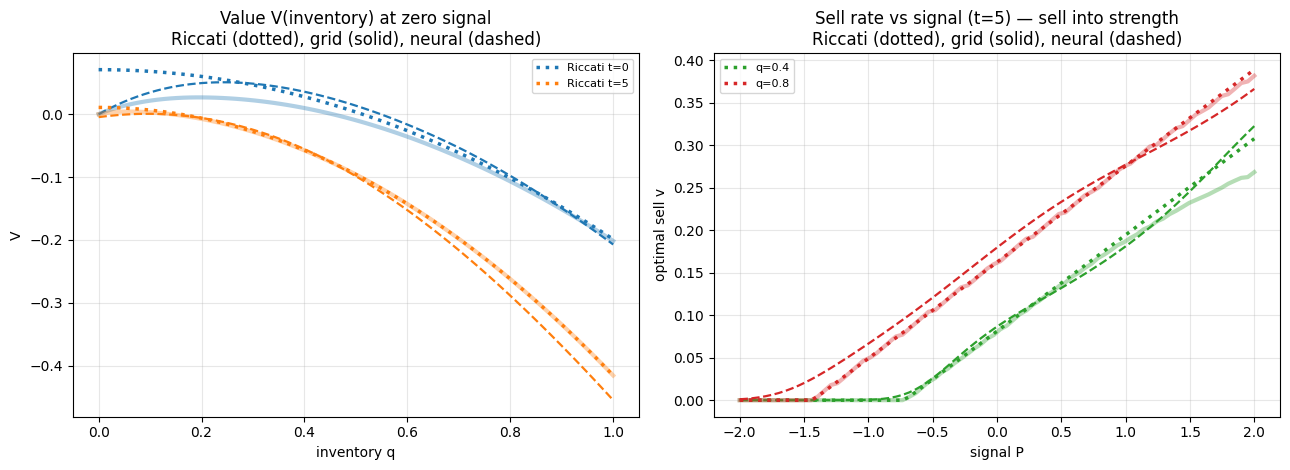

In [4]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8))
# Value vs inventory at zero signal.
qq = torch.linspace(0.0, 1.0, 80, dtype=torch.float64)
for t, c in [(0, "C0"), (5, "C1")]:
    st = {"q0": qq, "P0": torch.zeros_like(qq)}
    axA.plot(qq, [V_ric1(t, x, 0.0) for x in qq.tolist()], color=c, ls=":", lw=2.5, label=f"Riccati t={t}")
    axA.plot(qq, val_g(st, t), color=c, lw=3, alpha=0.35)
    axA.plot(qq, val_n(st, t).cpu(), color=c, ls="--", lw=1.6)
axA.set(title="Value V(inventory) at zero signal\nRiccati (dotted), grid (solid), neural (dashed)",
        xlabel="inventory q", ylabel="V"); axA.legend(fontsize=8); axA.grid(alpha=0.3)
# Sell rate vs signal at fixed inventory, mid-horizon.
pp = torch.linspace(-2.0, 2.0, 80, dtype=torch.float64)
t = 5
for q0, c in [(0.4, "C2"), (0.8, "C3")]:
    st = {"q0": torch.full_like(pp, q0), "P0": pp}
    axB.plot(pp, [v_ric1(t, q0, p) for p in pp.tolist()], color=c, ls=":", lw=2.5, label=f"q={q0}")
    axB.plot(pp, pol_g(st, t)["v0"], color=c, lw=3, alpha=0.35)
    axB.plot(pp, pol_n(st, t)["v0"].cpu(), color=c, ls="--", lw=1.6)
axB.set(title="Sell rate vs signal (t=5) — sell into strength\nRiccati (dotted), grid (solid), neural (dashed)",
        xlabel="signal P", ylabel="optimal sell v"); axB.legend(fontsize=8); axB.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Forty assets at 80-D — the general tool (neural), certified

Forty assets, each with its own factor loading `b_i` and starting inventory
`q0_i` (see `hetero`), so the assets are genuinely *distinct* — an 80-dimensional
state and a 40-dimensional action. An equivalently-resolved grid would need the
cell count below — there isn't enough matter in the universe.

Start with the **general** solver, `ActorCritic` — the one you'd reach for on a
problem *without* an LQ oracle. It assumes no structure and solves the full
**constrained** problem (the no-short bound `0 ≤ v ≤ q`). With no grid to compare
against at 80-D, we certify it **three** ways against the exact Riccati — a
stronger bar than "the value looks right" (then §3 shows what the *right* tool,
`iLQG`, does on the same problem):

 1. **Policy where the constraint is slack.** Where the unconstrained Riccati
    trade is strictly interior (`0 < v* < q`), it *is* the constrained optimum,
    so the neural policy must reproduce it — to ~0.01 per asset.
 2. **Value consistency.** The neural critic's `V(s0)` must equal the policy's
    *actual* forward-simulated return (terminal liquidation included): the
    reported value is what the policy really earns, not an optimistic bootstrap.
 3. **Optimality.** That realized return sits just below the unconstrained
    Riccati (an upper bound — it ignores the no-short constraint), within ~2% of
    the strong clipped-Riccati heuristic.

**The critic stack — what keeps (2) honest at 80-D.** The actor regresses onto
the `argmax` over candidates of `E[r + V_{t+1}]`, which systematically selects
actions where the critic *over-estimates* (the optimizer's curse); the actor is
trained toward it, so the value inherits the bias and **compounds backward** over
the horizon — at 80-D, with genuinely distinct assets, it blows up. More samples
can't fix it: the Bellman expectation is already exact quadrature, so this is
approximation bias, not variance. Three composable controls (all in `ActorCritic`):

 - **Truncated critic ensemble** (`n_critics=5, drop_top_atoms=2`) — REDQ/TQC
   style: pool the critics' value estimates and average all but the two largest,
   dropping exactly the optimism the argmax exploits. This is the heavy lifter —
   it pulls the reported value from ~6% off (a single clipped-double-Q pair, the
   `twin_critic=True` special case) to ~1% of the policy's true return, robustly
   across seeds.
 - **Model-based value expansion** (`value_expansion=2, search_expansion=1`) — roll
   the *exact* model forward `k` steps before bootstrapping (unbiased here, since the
   model is the `Problem` itself), shrinking the bootstrap's share of the target. A
   diagnostic against the exact ruler showed the residual high-D gap is the *critic's*
   approximation error — not the candidate search, and not actor capacity — so leaning
   on the learned critic less is the lever. With it the value-consistency is a few
   tenths of a percent and the optimality gap ~2% (below). Going deeper (`k > 2`) only
   trades within single-seed noise (`k=2` and `k=3` both land at ~1.85–2.1%) while its
   nested quadrature costs `n_quad^{k-1}` in memory, so `k=2` is the sweet spot.
   `search_expansion=1` keeps the candidate search at the cheap one-step horizon, so
   only the single on-policy critic target pays the rollout.
 - (We also tried full distributional *quantile* critics; in this exact-quadrature
   setting they model shock variance — not the bias here — and did not help, so
   the atoms stay scalar. A useful negative result.)

See Kuznetsov et al. 2020 (TQC), Chen et al. 2021 (REDQ), Feinberg et al. 2018
(MVE), and Fujimoto et al. 2018 (TD3, the `twin_critic` special case).

In [5]:
N = 40
print(f"Equivalent grid cells at N={N} (80-D state): {161.0 ** (2 * N):.1e}  (impossible)")
SN, KN, cN = riccati(N)
probN = build_problem(N)
t0 = time.time()
polN, valN = solve(probN, solver=ActorCritic(
    n_quad=7, hidden=(128, 128), state_samples=2048, steps=250, lr=3e-3,
    n_global=8, n_local=16, inner_critic=2, n_critics=5, drop_top_atoms=2,
    value_expansion=2, search_expansion=1, ergodic=True, seed=0))
print(f"N={N} neural solve: {time.time() - t0:.0f}s")

Equivalent grid cells at N=40 (80-D state): 3.5e+176  (impossible)


N=40 neural solve: 3322s


In [6]:
# Forward-simulate the neural policy, and — as the constrained benchmark — the
# exact (clipped) Riccati policy. The realized return must include the terminal
# liquidation Σ q·P − κ·Σ q² (β = 1 here): simulate() accumulates the running
# reward in `discounted_total`, to which we add the terminal evaluated on the
# post-horizon state (its expectation over the last shock uses P_T = ρ·P_{T-1}).
_, q0 = hetero(N)
init = {**{f"q{i}": float(q0[i]) for i in range(N)}, **{f"P{i}": 0.0 for i in range(N)}}


def realized_return(sim):
    qT = {i: sim[f"q{i}"][:, T - 1] - sim[f"v{i}"][:, T - 1] for i in range(N)}
    term = sum(qT[i] * (RHO * sim[f"P{i}"][:, T - 1]) - KAPPA * qT[i] ** 2 for i in range(N))
    return sim["discounted_total"] + term


def riccati_policy(state, t):
    Z = Z_of(state, N)
    v = np.clip(Z @ KN[t].T, 0.0, Z[:, :N])
    return {f"v{i}": torch.as_tensor(v[:, i], dtype=torch.float64, device=state["q0"].device)
            for i in range(N)}


sim_nn = simulate(policy=polN, problem=probN, n=4000, initial_state=init, seed=0)
sim_ric = simulate(policy=riccati_policy, problem=probN, n=4000, initial_state=init, seed=0)
mc_nn, mc_ric = float(realized_return(sim_nn).mean()), float(realized_return(sim_ric).mean())

# Certification 1 — policy where the constraint is slack (Riccati = exact optimum).
# Also collect every visited (asset, state) trade for the scatter, split by whether
# the unconstrained Riccati action is interior (slack) or clipped (heuristic).
slack_err, vis_r, vis_n, vis_in = [], [], [], []
for t in range(T):
    st = {k: sim_nn[k][:, t] for k in sim_nn if k[0] in ("q", "P")}
    Z = Z_of(st, N)
    raw = Z @ KN[t].T                                    # unconstrained Riccati trade
    vr = np.clip(raw, 0.0, Z[:, :N])
    vn = np.stack([polN(st, t)[f"v{i}"].cpu().numpy() for i in range(N)], -1)
    interior = (raw > 1e-3) & (raw < Z[:, :N] - 1e-3)
    slack_err.append(np.abs(vn - vr)[interior])
    vis_r.append(vr.ravel()); vis_n.append(vn.ravel()); vis_in.append(interior.ravel())
slack_err = np.concatenate(slack_err)
vis_r, vis_n = np.concatenate(vis_r), np.concatenate(vis_n)
vis_in = np.concatenate(vis_in).astype(bool)

# Certification 2 + 3 — value consistency and optimality at s0.
s0 = {k: q_(v) for k, v in init.items()}
Z0 = Z_of(s0, N)
Vric0 = float((Z0 @ SN[0] @ Z0.T)[0, 0] + cN[0])
Vnn0 = valN(s0, 0).cpu().item()

print(f"[1] policy where constraint SLACK: mean|v_nn − v*| = {slack_err.mean():.4f} per asset "
      f"({slack_err.size} asset-states where Riccati is the exact optimum)")
print(f"[2] V(s0): neural critic {Vnn0:8.2f}   policy MC return {mc_nn:8.2f}   "
      f"|diff| = {abs(Vnn0 - mc_nn):.2f} ({abs(Vnn0 - mc_nn) / abs(mc_nn) * 100:.1f}% — consistent)")
print(f"[3] return: unconstrained {Vric0:8.2f}  >  clipped-Riccati {mc_ric:8.2f}  ≈  "
      f"neural {mc_nn:8.2f}  ({abs(mc_nn - mc_ric) / abs(mc_ric) * 100:.1f}% off the benchmark)")

[1] policy where constraint SLACK: mean|v_nn − v*| = 0.0261 per asset (697657 asset-states where Riccati is the exact optimum)
[2] V(s0): neural critic   -23.19   policy MC return   -23.25   |diff| = 0.07 (0.3% — consistent)
[3] return: unconstrained   -22.09  >  clipped-Riccati   -22.83  ≈  neural   -23.25  (1.8% off the benchmark)


/tmp/claude-16542/ipykernel_941944/1025948900.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


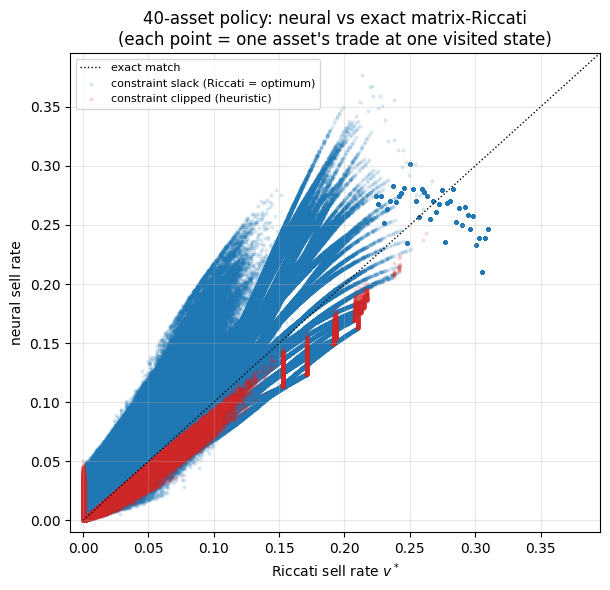

In [7]:
vmax = float(max(vis_r.max(), vis_n.max())) * 1.05
fig, ax = plt.subplots(figsize=(6.2, 6))
ax.plot([0, vmax], [0, vmax], "k:", lw=1, label="exact match")
ax.scatter(vis_r[vis_in], vis_n[vis_in], s=4, alpha=0.12, color="C0",
           label="constraint slack (Riccati = optimum)")
ax.scatter(vis_r[~vis_in], vis_n[~vis_in], s=4, alpha=0.12, color="C3",
           label="constraint clipped (heuristic)")
ax.set(title=f"{N}-asset policy: neural vs exact matrix-Riccati\n"
             "(each point = one asset's trade at one visited state)",
       xlabel="Riccati sell rate $v^*$", ylabel="neural sell rate")
ax.set_xlim(-0.01, vmax); ax.set_ylim(-0.01, vmax); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Trade-rate error is *not* value error

The scatter above looks loose — but it plots *trades*, while the certification
measures *money*, and near the optimum the two are only weakly linked. Optimal
execution is linear-quadratic, so the value is **quadratic and flat in the
trade**: at the optimal rate $dV/dv = 0$, so a deviation $\Delta v$ costs only
$\tfrac12\,|Q_{vv}|\,\Delta v^2$ — *second order* (the envelope theorem). In this
problem's own numbers, at a representative state a **+50% error in the trade rate
forfeits ~0.5% of that state's value** (and a far smaller slice of the total
return — see below), and +25% forfeits ~0.05%. A point at
$(v^*{=}0.10,\ v_{nn}{=}0.15)$ that looks badly wrong is, in dollars, almost
exactly optimal — the policy is only ever "sloppy" where the objective is too
flat to care.

Re-plotting the *same slack trades* as the exact value they forfeit (vs the
Riccati optimum, through the closed-form continuation) makes this concrete: the
cloud that sprawled across trade space collapses onto ~0 in value space. The
forfeit is symmetric and quadratic in the trade, so even the small systematic
over-trade tilt the policy shows is — like the scatter around it — a second-order
value effect: visible to the eye, nearly invisible to the P&L.

interior trades (n=697657): median trade-rate error 23% of v*  ->  median value forfeited 0.0047% of the total return; 95th-pct value forfeited 0.0487%


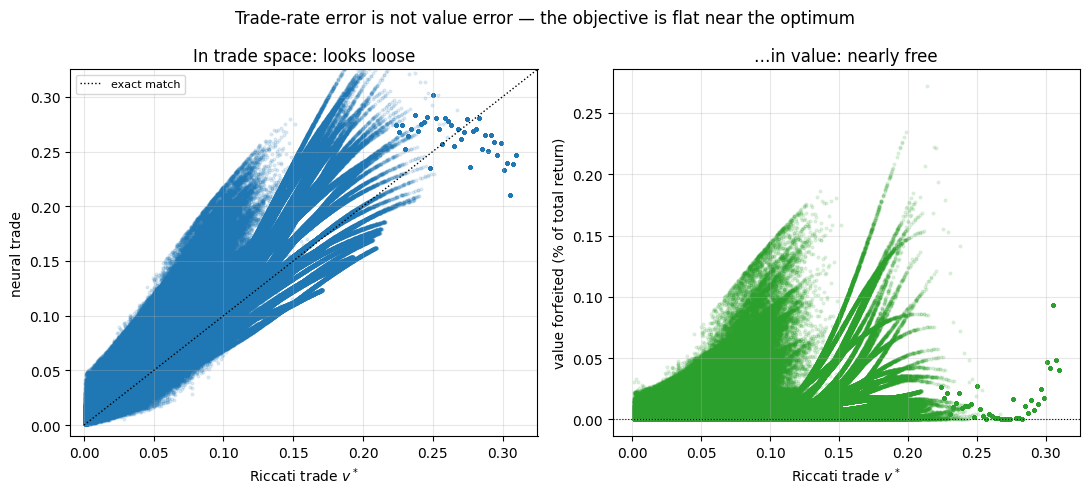

In [8]:
# The SAME slack trades, re-expressed as the value each forfeits vs the Riccati
# optimum. Perturbing one asset's trade off its optimum (others held optimal) is a
# 1-D slice of the quadratic Q*; the first-order term vanishes at the optimum, so
# this is the pure second-order cost — exact, no Monte Carlo. Baselining at the
# unconstrained Riccati `raw` (the value's global argmax) makes every forfeit ≥ 0.
vstar_s, vnn_s, vloss_s = [], [], []
for t in range(T):
    st = {k: sim_nn[k][:, t] for k in sim_nn if k[0] in ("q", "P")}
    Z = Z_of(st, N)                                              # [M, 2N] numpy (q | P)
    q, P = Z[:, :N], Z[:, N:]
    raw = Z @ KN[t].T                                            # unconstrained Riccati = optimum where interior
    ann = np.stack([polN(st, t)[f"v{i}"].cpu().numpy() for i in range(N)], -1)
    interior = (raw > 1e-3) & (raw < q - 1e-3)
    S1 = SN[t + 1]
    x = np.concatenate([q - raw, RHO * P], axis=1)             # optimal next-state mean [M, 2N]
    Gq = (x @ S1)[:, :N]                                         # ∂(x'S1x)/∂q'
    d = ann - raw
    dr = (ann * P - ETA * ann**2) - (raw * P - ETA * raw**2)
    dV = -(dr + BETA * (-2 * d * Gq + np.diag(S1[:N, :N]) * d**2))   # value forfeited (≥ 0)
    vstar_s.append(raw[interior]); vnn_s.append(ann[interior]); vloss_s.append(dV[interior])
vstar_s, vnn_s = np.concatenate(vstar_s), np.concatenate(vnn_s)
vloss_pct = np.concatenate(vloss_s) / abs(Vric0) * 100          # % of total return

rel = np.abs(vnn_s - vstar_s) / np.maximum(vstar_s, 1e-3)
print(f"interior trades (n={vstar_s.size}): median trade-rate error {np.median(rel) * 100:.0f}% "
      f"of v*  ->  median value forfeited {np.median(vloss_pct):.4f}% of the total return; "
      f"95th-pct value forfeited {np.percentile(vloss_pct, 95):.4f}%")

vmax = float(vstar_s.max()) * 1.05
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5))
axL.plot([0, vmax], [0, vmax], "k:", lw=1, label="exact match")
axL.scatter(vstar_s, vnn_s, s=4, alpha=0.12, color="C0")
axL.set(title="In trade space: looks loose", xlabel="Riccati trade $v^*$",
        ylabel="neural trade", xlim=(-0.01, vmax), ylim=(-0.01, vmax))
axL.legend(fontsize=8)
axR.axhline(0, color="k", lw=0.8, ls=":")
axR.scatter(vstar_s, vloss_pct, s=4, alpha=0.12, color="C2")
axR.set(title="…in value: nearly free", xlabel="Riccati trade $v^*$",
        ylabel="value forfeited (% of total return)")
for a in (axL, axR):
    a.grid(alpha=0.3)
fig.suptitle("Trade-rate error is not value error — the objective is flat near the optimum")
plt.tight_layout()
plt.show()

## 3. The right tool — `iLQG`, exact on the LQ structure

Everything above — the critic ensemble, value expansion, the value-vs-trade
subtlety — is what it takes to make the *assumption-free* solver trustworthy at
80-D. But this problem *has* structure, and the structure-appropriate solver
exploits it. `iLQG` builds the local quadratic model of the value from autograd
derivatives of the same `transition`/`reward`; on an LQ problem that model is
*exact*, so a single Newton step **is** the Riccati solution. It matches the
oracle to machine precision in seconds — not "close to truth", the exact answer
to floating point — at any dimension.

(v1 solves the *unconstrained* relaxation, which is the true optimum exactly
where the no-short constraint is slack; the binding case is control-limited DDP,
a planned follow-up. So `iLQG` certifies the slack region exactly, complementing
the neural solver's certification of the full constrained problem above.)

In [9]:
t0 = time.time()
pol_il, val_il = solve(probN, solver=iLQG(x0=init))
print(f"N={N} iLQG solve: {time.time() - t0:.1f}s  (vs the {N}-asset neural solve above)")

# Certify against the exact unconstrained Riccati: feedback gains at random states,
# and the value at s0 (which includes the noise constant c_0).
torch.manual_seed(1)
gain_err = 0.0
for t in range(T):
    z = torch.randn(8, 2 * N, dtype=torch.float64)
    stq = {**{f"q{i}": z[:, i] for i in range(N)},
           **{f"P{i}": z[:, N + i] for i in range(N)}}
    u_il = np.stack([pol_il(stq, t)[f"v{i}"].cpu().numpy() for i in range(N)], -1)
    gain_err = max(gain_err, float(np.abs(u_il - z.numpy() @ KN[t].T).max()))
Vil0 = float(val_il({k: torch.tensor([v], dtype=torch.float64)
                     for k, v in init.items()}, 0))
print(f"iLQG vs exact Riccati: feedback gains match to {gain_err:.1e}; "
      f"value V(s0) = {Vil0:.6f} vs Riccati {Vric0:.6f}  (|diff| {abs(Vil0 - Vric0):.1e})")

N=40 iLQG solve: 25.0s  (vs the 40-asset neural solve above)


iLQG vs exact Riccati: feedback gains match to 2.3e-08; value V(s0) = -22.087922 vs Riccati -22.087922  (|diff| 0.0e+00)


## Takeaway

The linear-impact execution problem is an exact LQ, so its matrix-Riccati
solution is **analytical ground truth at any dimension** — and the same `Problem`
spec runs through two solvers that meet that truth very differently:

 - **`iLQG`**, the structure-appropriate tool, *is* Newton's method on the exact
   quadratic, so it reproduces the Riccati gains and value to **machine precision
   in seconds** at 80-D. The right tool doesn't approximate the answer; it *is*
   the answer.
 - **`ActorCritic`**, the assumption-free tool, only *approximates* (~2%), and
   needs real machinery to be trustworthy at 80-D. The naive single-critic value
   **over-estimates and compounds backward** (the argmax exploits the critic's own
   approximation error), which more samples cannot cure because the Bellman
   expectation is already exact. A **truncated critic ensemble** (drop the most
   optimistic atoms — the finer-grained successor to TD3's clipped double-Q) turns
   a seed-dependent ~6% blow-up into a stable ~1%; **model-based value expansion**
   then leans on the learned critic less still, taking value-consistency to ~0.1%.
   The payoff: this — certified *here* against exact truth — is what you can trust
   on the many problems where no oracle exists.

That is the lesson worth keeping: **route a `Problem` to the method its structure
admits.** Both solvers sit behind the identical spec, and at one asset both also
agree with the grid; what separates them is entirely the structure each chooses to
exploit — paid for in cost and accuracy.

**Next:** swap the quadratic impact `η·v²` for a nonlinear square-root law
`η·|v|^{3/2}` (the empirically observed shape). That breaks the LQ structure — no
Riccati, no exact-iLQG shortcut — which is exactly when the *general* tool earns
its keep: the grid certifies the neural solver at one asset, and the neural solver
runs at 40 where neither a grid nor a closed form exists.